### **Pandas + HTML**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [26]:
url = "https://uk.wikipedia.org/wiki/Населення_України"

headers = {
    "User-Agent": "Chrome/146.0.7680.178"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(
    response.text,
    attrs={"class": "wikitable collapsible collapsed"}
)

df = tables[3]

C:\Users\Home\AppData\Local\Temp\ipykernel_36184\1495378657.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(


In [27]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,—,—
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,—


In [28]:
df.shape

(28, 9)

In [29]:
df.replace("—", np.nan)

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,NaN,NaN
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,NaN
5,Житомирська,261.0,223.0,159.0,129,89,122,120,79
6,Закарпатська,314.0,273.0,207.0,168,115,151,146,104
7,Запорізька,219.0,197.0,150.0,124,71,106,106,68
8,Івано-Франківська,243.0,248.0,182.0,155,103,124,122,88
9,Київська,204.0,189.0,156.0,123,73,122,121,80


In [30]:
df.dtypes

Регіон     object
1950      float64
1960      float64
1970      float64
1990        int64
2000        int64
2012        int64
2014       object
2019       object
dtype: object

In [31]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [32]:
df.isnull().sum() / len(df)

Регіон    0.000000
1950      0.071429
1960      0.035714
1970      0.035714
1990      0.000000
2000      0.000000
2012      0.000000
2014      0.071429
2019      0.142857
dtype: float64

In [33]:
df.drop(df.index[-1])

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,NaN,NaN
1,Вінницька,224.0,192.0,142.0,124,84,112,109.0,76.0
2,Волинська,247.0,250.0,179.0,153,112,148,141.0,101.0
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111.0,71.0
4,Донецька,271.0,214.0,140.0,109,61,98,82.0,NaN
5,Житомирська,261.0,223.0,159.0,129,89,122,120.0,79.0
6,Закарпатська,314.0,273.0,207.0,168,115,151,146.0,104.0
7,Запорізька,219.0,197.0,150.0,124,71,106,106.0,68.0
8,Івано-Франківська,243.0,248.0,182.0,155,103,124,122.0,88.0
9,Київська,204.0,189.0,156.0,123,73,122,121.0,80.0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [34]:
df.loc[df["2014"].idxmax()]

Регіон    Рівненська
1950           269.0
1960           267.0
1970           193.0
1990             158
2000             118
2012             159
2014           148.0
2019           107.0
Name: 16, dtype: object

In [ ]:
mean_2019 = df['2019'].mean()
df[df['2019'] > mean_2019]['Регіон']

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.000000,206.000000,160.000000,130,73,126,111.423077,80.208333
1,Вінницька,224.000000,192.000000,142.000000,124,84,112,109.000000,76.000000
2,Волинська,247.000000,250.000000,179.000000,153,112,148,141.000000,101.000000
3,Дніпропетровська,204.000000,204.000000,151.000000,123,71,112,111.000000,71.000000
4,Донецька,271.000000,214.000000,140.000000,109,61,98,82.000000,80.208333
5,Житомирська,261.000000,223.000000,159.000000,129,89,122,120.000000,79.000000
6,Закарпатська,314.000000,273.000000,207.000000,168,115,151,146.000000,104.000000
7,Запорізька,219.000000,197.000000,150.000000,124,71,106,106.000000,68.000000
8,Івано-Франківська,243.000000,248.000000,182.000000,155,103,124,122.000000,88.000000
9,Київська,204.000000,189.000000,156.000000,123,73,122,121.000000,80.000000


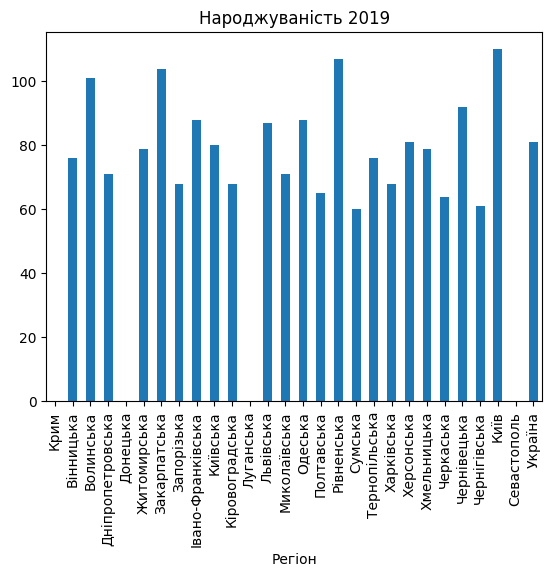

In [38]:
df.set_index("Регіон")["2019"].plot(kind="bar")
plt.title("Народжуваність 2019")
plt.show()